In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

<Axes: xlabel='age', ylabel='Count'>

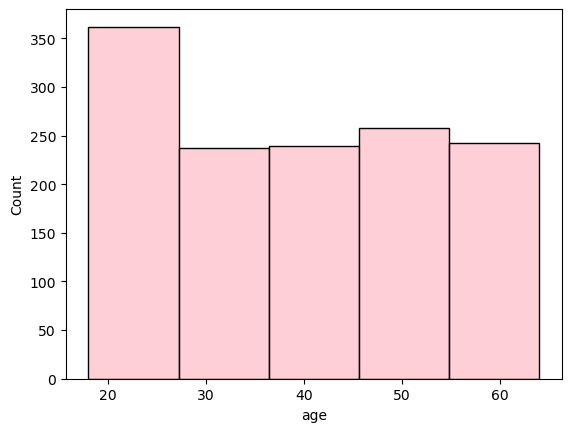

In [8]:
sns.histplot (data= df['age'], bins= 5 , color= 'pink')

<Axes: ylabel='sex'>

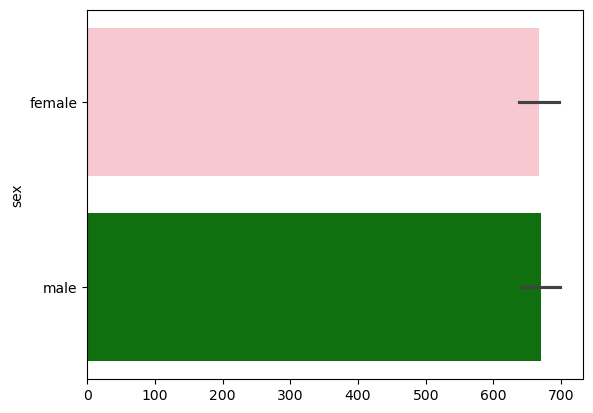

In [9]:
sns.barplot(data= df['sex'], palette= {'female' : "pink", 'male' : "green"})

<Axes: >

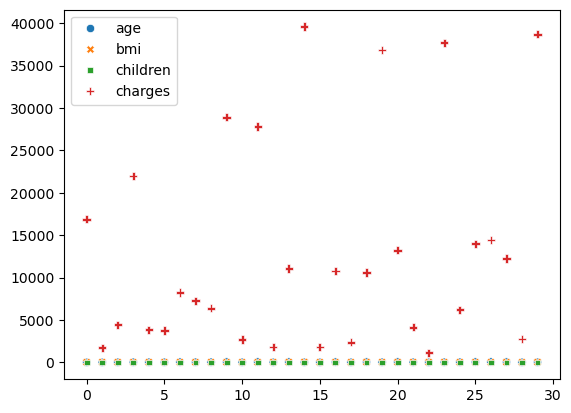

In [10]:
sns.scatterplot ( data= df.head(30))

<Axes: >

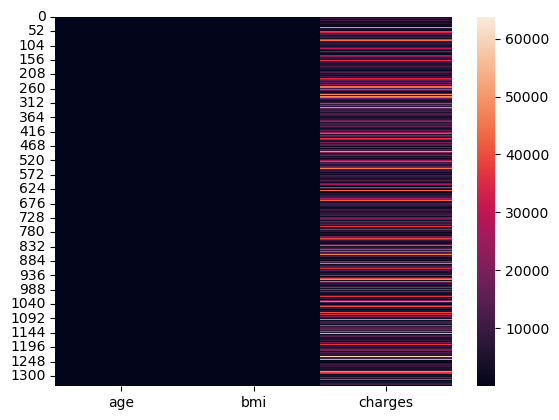

In [11]:
sns.heatmap ( data= df[['age', 'bmi','charges']])

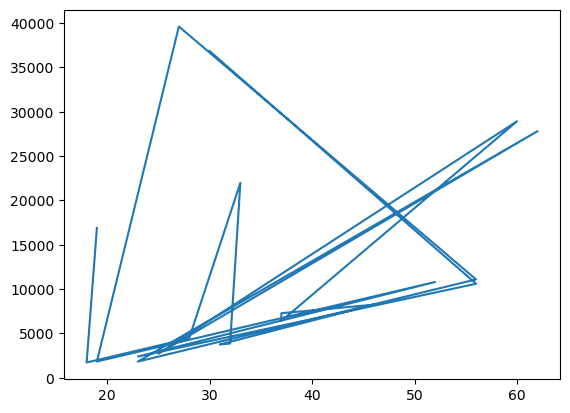

In [12]:
plt.plot(df['age'].head(20),df['charges'].head(20))

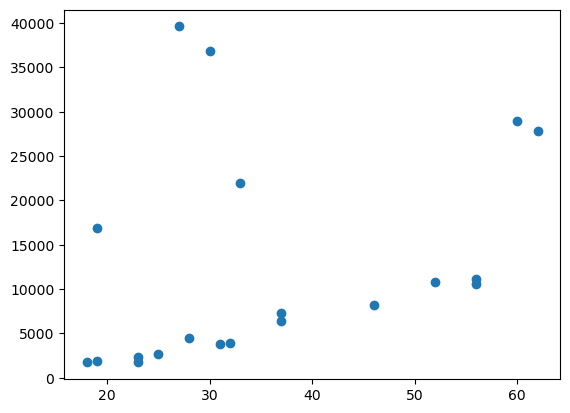

In [13]:
plt.scatter( x= df['age'].head(20), y= df['charges'].head(20))

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
df['IsFemale'] = df['sex'].map({"male": 0, "female": 1})

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges,IsFemale
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [17]:
df = df.drop('sex',axis= 1)

In [18]:
df.head()

,age,bmi,children,smoker,region,charges,IsFemale
0,19,27.900,0,yes,southwest,16884.92400,1
1,18,33.770,1,no,southeast,1725.55230,0
2,28,33.000,3,no,southeast,4449.46200,0
3,33,22.705,0,no,northwest,21984.47061,0
4,32,28.880,0,no,northwest,3866.85520,0


In [19]:
df["smoker"] = df['smoker'].map({"yes": 1, "no":0})
df.head()

,age,bmi,children,smoker,region,charges,IsFemale
0,19,27.900,0,1,southwest,16884.92400,1
1,18,33.770,1,0,southeast,1725.55230,0
2,28,33.000,3,0,southeast,4449.46200,0
3,33,22.705,0,0,northwest,21984.47061,0
4,32,28.880,0,0,northwest,3866.85520,0


In [20]:
df = pd.concat([df,pd.get_dummies(df['region'])], axis=1)
df.head()

,age,bmi,children,smoker,region,charges,IsFemale,northeast,northwest,southeast,southwest
0,19,27.900,0,1,southwest,16884.92400,1,False,False,False,True
1,18,33.770,1,0,southeast,1725.55230,0,False,False,True,False
2,28,33.000,3,0,southeast,4449.46200,0,False,False,True,False
3,33,22.705,0,0,northwest,21984.47061,0,False,True,False,False
4,32,28.880,0,0,northwest,3866.85520,0,False,True,False,False


In [21]:
df.drop('region', axis=  1, inplace= True)
df.head()

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest
0,19,27.900,0,1,16884.92400,1,False,False,False,True
1,18,33.770,1,0,1725.55230,0,False,False,True,False
2,28,33.000,3,0,4449.46200,0,False,False,True,False
3,33,22.705,0,0,21984.47061,0,False,True,False,False
4,32,28.880,0,0,3866.85520,0,False,True,False,False


In [22]:
df = df.astype(int)
df.head()

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest
0,19,27,0,1,16884,1,0,0,0,1
1,18,33,1,0,1725,0,0,0,1,0
2,28,33,3,0,4449,0,0,0,1,0
3,33,22,0,0,21984,0,0,1,0,0
4,32,28,0,0,3866,0,0,1,0,0


In [23]:
df['bmi'].max()

53

In [24]:
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [25]:
df.head()

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest,bmi_category
0,19,27,0,1,16884,1,0,0,0,1,Overweight
1,18,33,1,0,1725,0,0,0,1,0,Obese
2,28,33,3,0,4449,0,0,0,1,0,Obese
3,33,22,0,0,21984,0,0,1,0,0,Normal
4,32,28,0,0,3866,0,0,1,0,0,Overweight


In [26]:
df = pd.concat([df,pd.get_dummies(df['bmi_category'])], axis=1)
df.head()

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest,bmi_category,Underweight,Normal,Overweight,Obese
0,19,27,0,1,16884,1,0,0,0,1,Overweight,False,False,True,False
1,18,33,1,0,1725,0,0,0,1,0,Obese,False,False,False,True
2,28,33,3,0,4449,0,0,0,1,0,Obese,False,False,False,True
3,33,22,0,0,21984,0,0,1,0,0,Normal,False,True,False,False
4,32,28,0,0,3866,0,0,1,0,0,Overweight,False,False,True,False


In [27]:
df = df.drop('bmi_category', axis= 1)
df = df.astype(int)
df.head()

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest,Underweight,Normal,Overweight,Obese
0,19,27,0,1,16884,1,0,0,0,1,0,0,1,0
1,18,33,1,0,1725,0,0,0,1,0,0,0,0,1
2,28,33,3,0,4449,0,0,0,1,0,0,0,0,1
3,33,22,0,0,21984,0,0,1,0,0,0,1,0,0
4,32,28,0,0,3866,0,0,1,0,0,0,0,1,0


In [28]:
from sklearn.preprocessing import StandardScaler
df [['age','bmi','children']] = StandardScaler().fit_transform(df [['age','bmi','children']])
df.head()

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest,Underweight,Normal,Overweight,Obese
0,-1.438764,-0.518122,-0.908614,1,16884,1,0,0,0,1,0,0,1,0
1,-1.509965,0.462657,-0.078767,0,1725,0,0,0,1,0,0,0,0,1
2,-0.797954,0.462657,1.580926,0,4449,0,0,0,1,0,0,0,0,1
3,-0.441948,-1.335438,-0.908614,0,21984,0,0,1,0,0,0,1,0,0
4,-0.513149,-0.354659,-0.908614,0,3866,0,0,1,0,0,0,0,1,0


<Axes: >

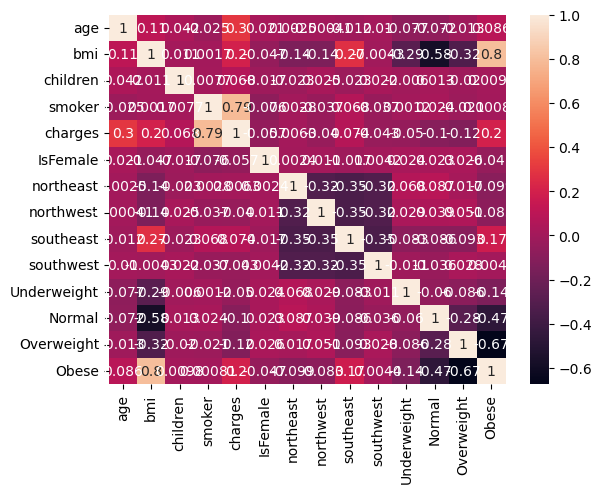

In [29]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [30]:
df.to_csv("cleaned_data.csv", index=False)

In [31]:
df

,age,bmi,children,smoker,charges,IsFemale,northeast,northwest,southeast,southwest,Underweight,Normal,Overweight,Obese
0,-1.438764,-0.518122,-0.908614,1,16884,1,0,0,0,1,0,0,1,0
1,-1.509965,0.462657,-0.078767,0,1725,0,0,0,1,0,0,0,0,1
2,-0.797954,0.462657,1.580926,0,4449,0,0,0,1,0,0,0,0,1
3,-0.441948,-1.335438,-0.908614,0,21984,0,0,1,0,0,0,1,0,0
4,-0.513149,-0.354659,-0.908614,0,3866,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,-0.027733,1.580926,0,10600,0,0,1,0,0,0,0,0,1
1334,-1.509965,0.135731,-0.908614,0,2205,1,1,0,0,0,0,0,0,1
1335,-1.509965,0.953046,-0.908614,0,1629,1,0,0,1,0,0,0,0,1
1336,-1.296362,-0.845048,-0.908614,0,2007,1,0,0,0,1,0,0,1,0


In [32]:
df.shape

(1338, 14)